<link rel="stylesheet" href="notebooks/styles.css">

<div class="title-wrap">
  <h1 class="title-main" style="font-weight: bold; font-size: 2.65rem; margin-bottom: 0.5rem;">
  Spatial Data Science Approaches to Wildfire Severity Modeling
</h1>
<h2 class="title-sub" style="font-style: italic; font-size: 1.8rem; margin-top: 0rem; margin-bottom: 0.2rem;">
  A GIS‑Driven, Tree‑Based Machine Learning Analysis of California Wildfires
</h2>
</div>

# Module 6A: *Fire Damage Tuning*
##### Version Number: 4.0
---
### Contents  
> *Random Forest Hypertuning*\
> *XGBoost Hypertuning*\
> *Export Optimum Configurations*
---
### Notes
12/26 TODO: **Need to update for all targets**\
This module **automatically** finds the optimal configuration of models based on the average F1 score of all target categories.

**WARNING** this module is very computation heavy
- Start with a **baseline model** for comparison.
- Test with multi-classification **tree-based models** (Random Forest, XGBoost) and LGBM.
- Use kfold **cross-validation** to tune hyperparameters for each model.
- Export optimal models

---
### Inputs

---
### Outputs  

`model_parameters.csv` - optimal parameters for each of the three models

---
### User Created Dependencies

In [1]:
import os
import sys

# Allow import of custom modules from the parent directory
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data_utils import *
from src.model_utils import *
from src.plot_utils import *

---

### Third Party Dependencies

In [2]:
# Core Python libraries
import numpy as np
import pandas as pd
import json

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and modeling
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Style
sns.set(style='whitegrid')
plt.rcParams["figure.dpi"] = 100

---

### Load File

In [3]:
train_X = pd.read_csv('../data/processed/train_X.csv')
test_X = pd.read_csv('../data/processed/test_X.csv')

train_y = pd.read_csv('../data/processed/train_y_ignition.csv').squeeze()
test_y = pd.read_csv('../data/processed/test_y_ignition.csv').squeeze()

---

In [4]:
default_RF_parameters= {
    'n_estimators': 100,
    'max_depth': None,
    'min_samples_split': 2,
    'max_features': 'sqrt',
    'class_weight': 'balanced'
}

default_XGB_parameters = { 'objective': 'multi:softmax', 
                          'num_class': 2, 
                          'n_estimators': 150, 
                          'max_depth': 6, 
                          'learning_rate': 0.1, 
                          'verbosity': 0 }

parameters = {
    'Random Forest': default_RF_parameters,
    'XGBoost': default_XGB_parameters
}

## Random Forest Classifier

This section evaluates Hypertuning and class-balancing options for SciKitLearns **RandomForestClassifier**. Options are tested utilizing kfold validation. 
- `n_estimators` [50, 100, 150]
- `max_depth` [5, 10, 15, 20]
- `min_samples_split_values` = [2, 5, 10, 20, 50]
- `max_features` ['sqrt', 'log2']

### Hyperparameter Tuning

#### Number of Estimators (n_estimators)

RF | n_estimators=50 | Test Macro F1 = 0.6238
RF | n_estimators=100 | Test Macro F1 = 0.6248
RF | n_estimators=150 | Test Macro F1 = 0.6259


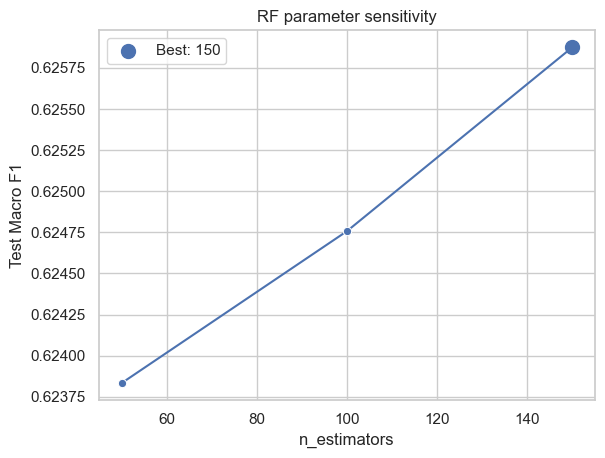

In [5]:
# Define parameter grid
estimators = [50, 100, 150]
optimum_n_estimator = test_values('RF','n_estimators',estimators, train_X, train_y, test_X, test_y, parameters, num_classes=2)

#### Maximum Tree Depth (max_depth)

In [6]:
# Define parameter grid
max_depth = [5, 10, 15, 20] 
optimum_max_depth = test_values('RF','max_depth',max_depth, train_X, train_y, test_X, test_y, parameters, num_classes=2)

RF | max_depth=5 | Test Macro F1 = 0.6632
RF | max_depth=10 | Test Macro F1 = 0.6831



KeyboardInterrupt



#### Maximum Features (max_features)

In [ ]:
# Define parameter grid
max_features = ['sqrt', 'log2']
optimum_max_features = test_values('RF','max_features',max_features, train_X, train_y, test_X, test_y, parameters, num_classes=2)

#### Minimum Sample Split  (min_samples)

In [ ]:
# Define parameter grid
min_samples_split_values = [2, 5, 10, 20, 50] 
optimum_min_samples_split = test_values('RF','min_samples_split',min_samples_split_values, train_X, train_y, test_X, test_y,parameters, num_classes=2)

### Final Random Forest Model

In [ ]:
RF_parameters = {
    'n_estimators': optimum_n_estimator,
    'max_depth': optimum_max_depth,
    'min_samples_split': optimum_min_samples_split,
    'max_features': optimum_max_features,
    'class_weight':'balanced'
}

pd.DataFrame([RF_parameters]).style \
    .hide(axis='index') \
    .set_caption("Optimum Random Forest Parameters")

---

## XGBoost Classifier

This section trains an XGBoost classifier using grid-based hyperparameter tuning and evaluates performance under different sampling strategies.

In [ ]:
default_XGB_parameters = { 'objective': 'multi:softmax', 
'num_class': 2, 
'n_estimators': 150, 
'max_depth': 6, 
'learning_rate': 0.1, 
'verbosity': 0 }

### Hyperparameter Tuning

#### n_estimators

In [ ]:
n_estimators = [50, 100, 150, 200]
optimum_n_estimator = test_values('XGB','n_estimators', n_estimators, train_X, train_y, test_X, test_y,parameters, num_classes=2)

#### learning_rate

In [ ]:
learning_rates = [0.1, 0.2, 0.3, 0.4]
optimum_learning_rate = test_values('XGB','learning_rate', learning_rates, train_X, train_y, test_X, test_y,parameters, num_classes=2)

#### max_depth

In [ ]:
max_depths = [3, 4, 5, 6]
optimum_max_depth = test_values('XGB','max_depth', max_depths, train_X, train_y, test_X, test_y,parameters, num_classes=2)

### Final XGBoost Model

In [ ]:
XGB_parameters = {
    'objective': 'multi:softmax',
    'num_class': 2,
    'n_estimators': optimum_n_estimator,
    'max_depth': optimum_max_depth,
    'learning_rate': optimum_learning_rate,
    'verbosity': 0
}

pd.DataFrame([XGB_parameters]).style \
    .hide(axis='index') \
    .set_caption("Optimum XGBoost Parameters")

---

## Export Data

In [ ]:
model_params = {
    'Random Forest': RF_parameters,
    'XGBoost': XGB_parameters,
}

In [ ]:
# Save to CSV

with open('../data/processed/model_parameters_ignition.json', 'w') as f:
    json.dump(model_params, f, indent=4)
    
print("All datasets saved successfully to ../data/processed/")